# Russell Westbrook — The Triple-Double King (2016-17 MVP season)

A basketball-analytics walkthrough of Westbrook's historic 2016-17 season — the whole
analysis (data, SQL, charts) in one scrollable page.

> **31.6 PPG · 10.7 RPG · 10.4 APG**, a triple-double in **51.9% of games**, **42**
> triple-doubles (a single-season record), and a **78.6% win rate** in those games.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")
import pandas as pd, duckdb
from IPython.display import Image
import build_dataset, viz

## 1. Build the dataset (and validate it)

Westbrook's 2016-17 game log comes from **Basketball-Reference** (one row per game). The
build validates against the record books (81 games, 42 triple-doubles, 31.6 / 10.7 / 10.4)
before going further.

In [2]:
gl = build_dataset.build()
df = pd.read_csv("data/processed/westbrook_2016_17_gamelog.csv")
df.head(10)

=== Russell Westbrook, 2016-17 — correctness gate ===
  games played    : 81      (expected 81)  OK
  triple-doubles  : 42      (expected 42)  OK
  points/game     : 31.6    (expected 31.6)  OK
  rebounds/game   : 10.7    (expected 10.7)  OK
  assists/game    : 10.4    (expected 10.4)  OK

Wrote 81 games -> /home/yungv/sports-analytics-portfolio/westbrook-mvp-2016-17/data/processed/westbrook_2016_17_gamelog.csv


,game_no,Date,month,Opp,Result,win,MP,PTS,TRB,AST,STL,BLK,TOV,FG%,3P%,triple_double
0,1,2016-10-26,Oct 2016,PHI,"W, 103-97",True,NaN,32.0,12.0,9.0,0.0,0.0,2.0,0.524,0.500,False
1,2,2016-10-28,Oct 2016,PHO,"W, 113-110 (OT)",True,NaN,51.0,13.0,10.0,2.0,0.0,5.0,0.386,0.200,True
2,3,2016-10-30,Oct 2016,LAL,"W, 113-96",True,NaN,33.0,11.0,16.0,1.0,1.0,7.0,0.524,0.833,True
3,4,2016-11-02,Nov 2016,LAC,"W, 85-83",True,NaN,35.0,6.0,5.0,3.0,0.0,10.0,0.467,0.000,False
4,5,2016-11-03,Nov 2016,GSW,"L, 96-122",False,NaN,20.0,6.0,10.0,1.0,2.0,6.0,0.267,0.500,False
5,6,2016-11-05,Nov 2016,MIN,"W, 112-92",True,NaN,28.0,6.0,8.0,3.0,0.0,2.0,0.500,0.800,False
6,7,2016-11-07,Nov 2016,MIA,"W, 97-85",True,NaN,14.0,5.0,11.0,0.0,0.0,5.0,0.313,0.167,False
7,8,2016-11-09,Nov 2016,TOR,"L, 102-112",False,NaN,36.0,7.0,7.0,1.0,2.0,8.0,0.346,0.250,False
8,9,2016-11-11,Nov 2016,LAC,"L, 108-110",False,NaN,29.0,14.0,9.0,1.0,0.0,4.0,0.360,0.600,False
9,10,2016-11-13,Nov 2016,ORL,"L, 117-119",False,NaN,41.0,12.0,16.0,0.0,0.0,2.0,0.667,0.000,True


## 2. A look with SQL (DuckDB)

Did the triple-doubles actually translate into wins, or were they "empty stats"?

In [3]:
con = duckdb.connect()
con.execute("CREATE VIEW g AS SELECT * FROM read_csv_auto('data/processed/westbrook_2016_17_gamelog.csv', header=true)")
con.execute('''
    SELECT CASE WHEN triple_double THEN 'Triple-double' ELSE 'No triple-double' END AS game_type,
           COUNT(*) AS games, SUM(win::INT) AS wins, SUM((NOT win)::INT) AS losses,
           ROUND(100.0*SUM(win::INT)/COUNT(*), 1) AS win_pct
    FROM g GROUP BY 1 ORDER BY win_pct DESC
''').df()

,game_type,games,wins,losses,win_pct
0,Triple-double,42,33.0,9.0,78.6
1,No triple-double,39,13.0,26.0,33.3


## 3. The story in charts

In [4]:
viz.run()

Saved charts -> outputs/01..06


### Chasing history — 42 triple-doubles (past Oscar Robertson's 41)

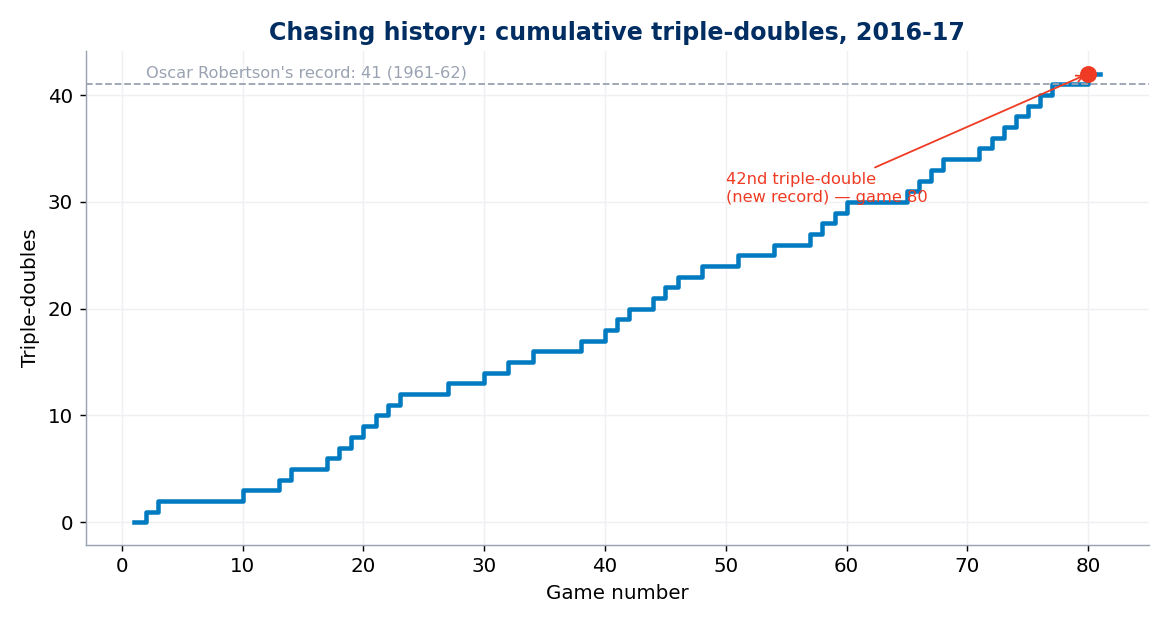

In [5]:
Image("outputs/01_cumulative_triple_doubles.png")

### He literally averaged a triple-double

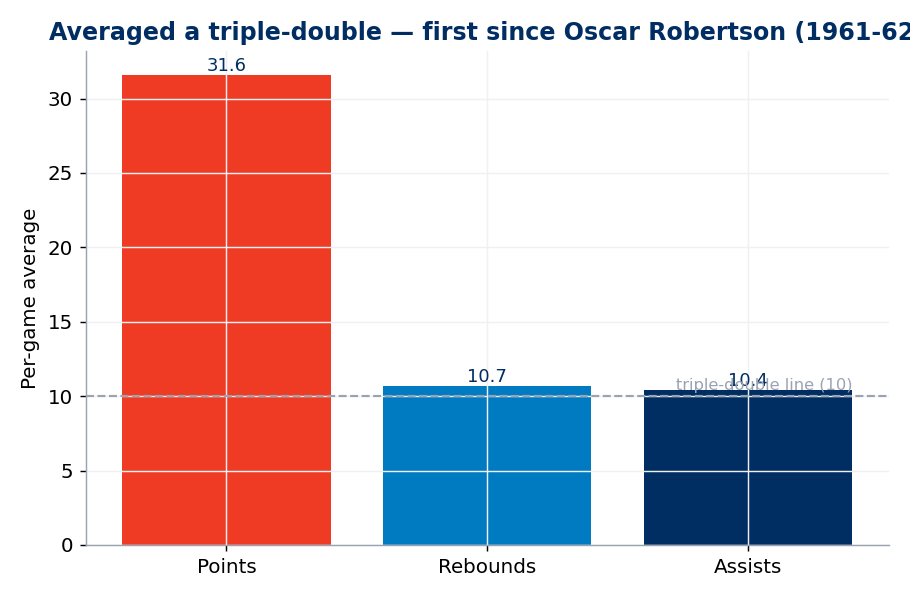

In [6]:
Image("outputs/02_season_averages.png")

### The triple-doubles won games — 78.6% vs 33.3%

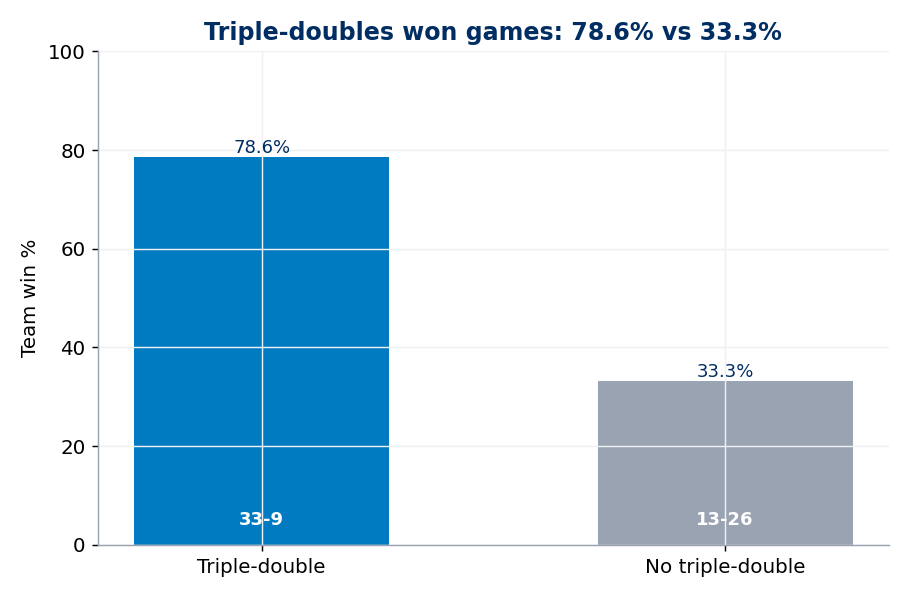

In [7]:
Image("outputs/03_triple_double_impact.png")

### Every game: rebounds vs assists (colour = points)

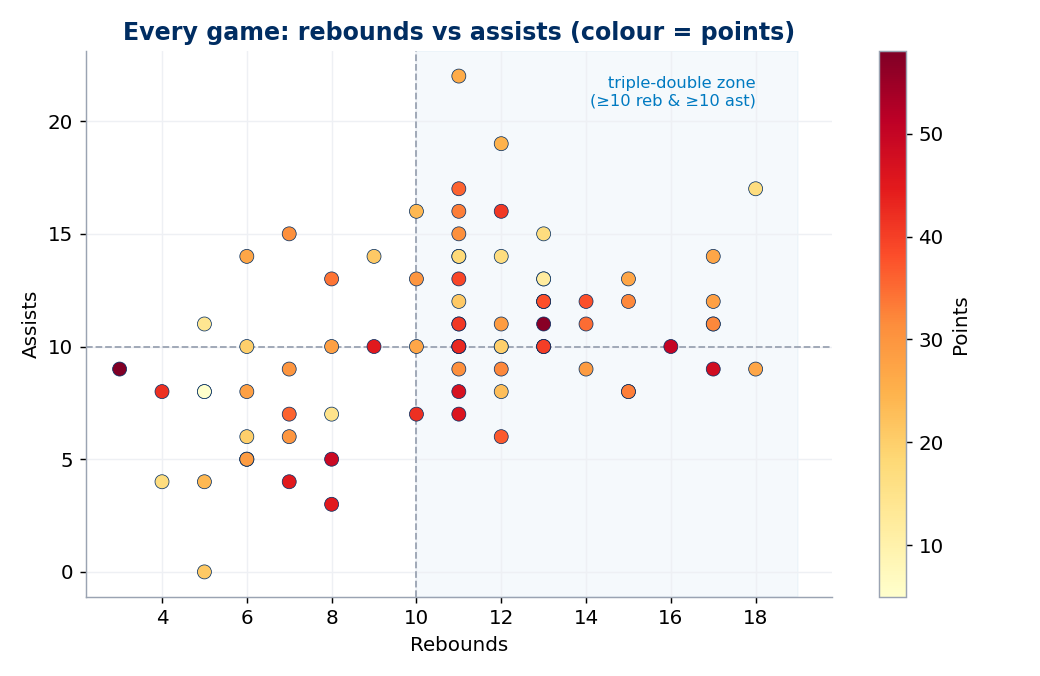

In [8]:
Image("outputs/04_rebounds_vs_assists.png")

## Takeaways
- A triple-double in **more than half** his games — and the Thunder **won 78.6%** of them.
- The first averaged triple-double season since Oscar Robertson (1961-62), with a record
  **42** triple-doubles.
- Full reproducible pipeline + sources are in this repo (`src/`, `SOURCES.md`).